In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
import glob
import re
from pathlib import Path
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, log_loss, mean_absolute_error, accuracy_score, f1_score, roc_auc_score
from sklearn.decomposition import TruncatedSVD
from lightgbm import LGBMRegressor, LGBMClassifier
import warnings
import hashlib

warnings.filterwarnings('ignore')

# ====================================================
# 🎛️ [CONTROL PANEL] 전역 설정 - 여기만 수정하세요!
# ====================================================
class Config:
    # ==========================================
    # 📁 경로 설정
    # ==========================================
    BASE_DIR = Path(r"C:\SEMIN\Project\ML_FINAL\1.BASE")
    FEATURE_DIR = Path(r"C:\SEMIN\Project\ML_FINAL\2.FEATURE")
    OUTPUT_DIR = Path(r"C:\SEMIN\Project\ML_FINAL\3.SELECTED")
    
    # ==========================================
    # 📊 데이터 컬럼명
    # ==========================================
    TARGET_COL = "gender"
    ID_COL = "custid"
    GROUP_COL = None  # GroupKFold 사용 시 그룹 컬럼명 (예: "user_id")
    
    # ==========================================
    # 🔧 모델 설정
    # ==========================================
    TASK_TYPE = "classification"  # "regression" 또는 "classification"
    CV_STRATEGY = "stratified"  # "kfold", "stratified", "group"
    N_FOLDS = 5
    RANDOM_STATE = 42
    
    # ==========================================
    # 📈 평가 지표 설정
    # ==========================================
    # 회귀: "rmse", "mae", "mse"
    # 분류: "logloss", "accuracy", "f1", "auc"
    EVAL_METRIC = "auc"  # 기본값 (회귀면 "rmse", 분류면 "logloss" 권장)
    
    # ==========================================
    # 🎯 피처 셀렉션 파라미터
    # ==========================================
    CORR_THRESHOLD = 0.95  # 다중공선성 임계값
    IMPORTANCE_TOP_K = 150  # 최종 선택 피처 개수
    MIN_FEATURE_SCORE = 0.001  # 빠른 스크리닝 최소 점수
    QUICK_TOP_N = 300       # 빠른 스크리닝에서 남길 최대 피처 수 (옵션)
    FINAL_TOP_N = 150       # 최종적으로 선택할 피처 수 (=IMPORTANCE_TOP_K와 용도 중복, 통일 권장)
    SVD_COMPONENTS = 10     # run_pipeline에서 SVD_N_COMPONENTS 대신 이 이름을 쓰고 있음
    
    # ==========================================
    # 🔬 고급 옵션
    # ==========================================
    USE_SVD = True  # SVD 파생 변수 생성 여부
    SVD_N_COMPONENTS = 10  # SVD 컴포넌트 개수
    USE_SHAP = True  # SHAP 값 계산 여부 (느림)
    SHAP_SAMPLE_SIZE = 1000  # SHAP 샘플링 크기
    PERM_N_REPEATS = 1  # Permutation Importance 반복 횟수
    
    # ==========================================
    # 📂 파일 패턴 (정규식)
    # ==========================================
    BASE_TRAIN_FILE = "train.csv"  # Base 학습 파일명
    BASE_TEST_FILE = "test.csv"  # Base 테스트 파일명
    TRAIN_PATTERN = r".*train.*\.csv$"  # Train 파일 패턴
    TEST_PATTERN = r".*test.*\.csv$"  # Test 파일 패턴

    # ==========================================
    # 🔗 교호항 생성 설정
    # ==========================================
    USE_INTERACTIONS = True
    INTERACTION_TOP_N = 10
    
    # 🔥 추가: 수치형 교호항
    NUMERIC_INTERACTION_METHODS = ['multiply', 'divide']
    INTERACTION_MIN_SCORE = 0.001  # 🔥 이거 추가!
    
    # 🔥 추가: 카테고리 교호항
    CREATE_CATEGORICAL_INTERACTIONS = False
    CATEGORICAL_INTERACTION_PAIRS = [
        ('browser', 'OS'),
        ('device', 'country')
    ]
    
    # ==========================================
    # 🔖 카테고리 보존 설정 (CatBoost용)
    # ==========================================
    KEEP_CATEGORICAL_COLS = ['browser', 'OS', 'device', 'country']  # 원본 유지
    CATEGORICAL_SCREENING = False  # 카테고리 교호항도 스크리닝
    
    # ==========================================
    # 📤 출력 파일명
    # ==========================================
    OUTPUT_TRAIN = "train_selected.csv"
    OUTPUT_TEST = "test_selected.csv"
    OUTPUT_IMPORTANCE = "feature_importance.csv"
    OUTPUT_PLOT = "importance.png"
    
    def __init__(self):
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        
    def print_config(self):
        """설정 정보 출력"""
        print("=" * 80)
        print("🎯 Feature Selection Pipeline 설정")
        print("=" * 80)
        print(f"📁 Base Directory: {self.BASE_DIR}")
        print(f"📁 Feature Directory: {self.FEATURE_DIR}")
        print(f"📁 Output Directory: {self.OUTPUT_DIR}")
        print(f"\n📊 Task Type: {self.TASK_TYPE}")
        print(f"📊 CV Strategy: {self.CV_STRATEGY.upper()}")
        if self.CV_STRATEGY == "group" and self.GROUP_COL:
            print(f"📊 Group Column: {self.GROUP_COL}")
        print(f"📊 CV Folds: {self.N_FOLDS}")
        print(f"📈 Evaluation Metric: {self.EVAL_METRIC.upper()}")
        print(f"\n🎯 Top K Features: {self.IMPORTANCE_TOP_K}")
        print(f"🎯 Correlation Threshold: {self.CORR_THRESHOLD}")
        print(f"🎯 Min Feature Score: {self.MIN_FEATURE_SCORE}")
        print(f"\n🔬 Use SVD: {self.USE_SVD}")
        if self.USE_SVD:
            print(f"🔬 SVD Components: {self.SVD_N_COMPONENTS}")
        print(f"🔬 Use SHAP: {self.USE_SHAP}")
        print("=" * 80 + "\n")

In [86]:
def read_csv_safe(file_path):
    """
    CSV 파일을 읽을 때 utf-8, cp949, euc-kr 순서로 시도하여
    인코딩 오류를 방지하는 함수입니다.
    """
    # 시도할 인코딩 리스트 (순서대로 시도)
    encodings = ['utf-8', 'cp949', 'euc-kr']
    
    for enc in encodings:
        try:
            # 해당 인코딩으로 읽기 시도
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            # 실패하면 다음 인코딩으로 넘어감
            continue
            
    # 모든 인코딩이 실패할 경우 에러 발생
    raise UnicodeDecodeError(f"❌ 파일 로드 실패: {file_path} (시도한 인코딩: {encodings})")

In [87]:
# ====================================================
# 📂 파일 탐지기
# ====================================================
class FileDetector:
    def __init__(self, feature_dir, train_pattern, test_pattern):
        self.feature_dir = feature_dir
        self.train_pattern = re.compile(train_pattern, re.IGNORECASE)
        self.test_pattern = re.compile(test_pattern, re.IGNORECASE)
    
    def find_files(self):
        """피처 파일 탐지"""
        print("\n📂 피처 파일 탐지 중...")
        all_files = list(self.feature_dir.glob("*.csv"))
        
        train_files = []
        test_files = []
        
        for file_path in all_files:
            if self.train_pattern.match(file_path.name):
                train_files.append(file_path)
            elif self.test_pattern.match(file_path.name):
                test_files.append(file_path)
        
        return sorted(train_files), sorted(test_files)
    
    def print_files(self, train_files, test_files):
        """파일 목록 출력"""
        print(f"\n{'='*70}")
        print(f"🟢 Train 파일 ({len(train_files)}개):")
        for f in train_files:
            print(f"   ✓ {f.name}")
        
        print(f"\n🔵 Test 파일 ({len(test_files)}개):")
        for f in test_files:
            print(f"   ✓ {f.name}")
        print(f"{'='*70}\n")
    
    def pair_files(self, train_files, test_files):
        """Train-Test 파일 페어링"""
        print("🔗 Train-Test 파일 페어링 중...\n")
        pairs = []
        unpaired_test = list(test_files)
        
        for train_file in train_files:
            train_base = re.sub(r'[_-]?train[_-]?', '', train_file.stem, flags=re.IGNORECASE)
            
            for test_file in unpaired_test:
                test_base = re.sub(r'[_-]?test[_-]?', '', test_file.stem, flags=re.IGNORECASE)
                
                if train_base.lower() == test_base.lower():
                    pairs.append((train_file, test_file))
                    unpaired_test.remove(test_file)
                    print(f"   ✓ {train_file.name} <-> {test_file.name}")
                    break
        
        print()
        return pairs

In [88]:
# ====================================================
# 🔍 피처 셀렉터
# ====================================================
class FeatureSelector:
    def __init__(self, task_type='regression', cv_strategy='kfold', group_col=None, 
                 eval_metric='rmse', random_state=42):
        self.task = task_type
        self.cv_strategy = cv_strategy
        self.group_col = group_col
        self.eval_metric = eval_metric.lower()
        self.random_state = random_state
        
        # 평가 지표 검증
        valid_regression = ['rmse', 'mae', 'mse']
        valid_classification = ['logloss', 'accuracy', 'f1', 'auc']
        
        if self.task == 'regression' and self.eval_metric not in valid_regression:
            print(f"⚠️ 회귀 문제에 맞지 않는 지표 '{self.eval_metric}'. RMSE로 변경합니다.")
            self.eval_metric = 'rmse'
        elif self.task == 'classification' and self.eval_metric not in valid_classification:
            print(f"⚠️ 분류 문제에 맞지 않는 지표 '{self.eval_metric}'. LogLoss로 변경합니다.")
            self.eval_metric = 'logloss'

    def _get_model(self):
        """모델 생성"""
        if self.task == 'classification':
            return LGBMClassifier(n_estimators=200, random_state=self.random_state, 
                                n_jobs=-1, verbose=-1)
        else:
            return LGBMRegressor(n_estimators=200, random_state=self.random_state, 
                               n_jobs=-1, verbose=-1)

    def _get_cv_strategy(self, y):
        """CV 전략 선택"""
        if self.cv_strategy == 'stratified':
            if self.task != 'classification':
                print("   ⚠️ Stratified는 분류 문제에서만 사용 가능. KFold로 전환.")
                return KFold(n_splits=5, shuffle=True, random_state=self.random_state)
            return StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        elif self.cv_strategy == 'group':
            return GroupKFold(n_splits=5)
        else:
            return KFold(n_splits=5, shuffle=True, random_state=self.random_state)

    def _compute_score(self, y_true, y_pred):
        """설정된 평가 지표로 점수 계산"""
        if self.eval_metric == 'rmse':
            return np.sqrt(mean_squared_error(y_true, y_pred))
        elif self.eval_metric == 'mae':
            return mean_absolute_error(y_true, y_pred)
        elif self.eval_metric == 'mse':
            return mean_squared_error(y_true, y_pred)
        elif self.eval_metric == 'logloss':
            return log_loss(y_true, y_pred)
        elif self.eval_metric == 'accuracy':
            return accuracy_score(y_true, (y_pred > 0.5).astype(int))
        elif self.eval_metric == 'f1':
            return f1_score(y_true, (y_pred > 0.5).astype(int), average='binary')
        elif self.eval_metric == 'auc':
            return roc_auc_score(y_true, y_pred)
        else:
            raise ValueError(f"지원하지 않는 평가 지표: {self.eval_metric}")

    def _compute_hash(self, df, feature_name):
        """피처 해시 계산 (중복 감지용)"""
        return hashlib.md5(df[feature_name].astype(str).values.tobytes()).hexdigest()

    def remove_constant(self, df, threshold=0.99):
        """[1/5] 상수 피처 제거"""
        print("🔍 [1/5] 상수 피처 제거 중...")
        drop_cols = []
        for col in df.columns:
            if df[col].nunique() <= 1:
                drop_cols.append(col)
            elif df[col].value_counts(normalize=True).iloc[0] > threshold:
                drop_cols.append(col)
        
        print(f"   -> 제거: {len(drop_cols)}개")
        return [c for c in df.columns if c not in drop_cols]

    def remove_duplicates(self, df, features):
        """[2/5] 중복 피처 제거"""
        print("🔍 [2/5] 중복 피처 제거 중...")
        duplicates = []
        hash_map = {}
        
        for feat in features:
            feat_hash = self._compute_hash(df, feat)
            if feat_hash in hash_map:
                duplicates.append(feat)
            else:
                hash_map[feat_hash] = feat
        
        print(f"   -> 제거: {len(duplicates)}개")
        return [f for f in features if f not in duplicates]

    def remove_collinear(self, df, features, threshold=0.98):
        """[3/5] 다중공선성 제거"""
        print(f"🔍 [3/5] 스마트 다중공선성 제거 중 (threshold={threshold})...")
        
        num_features = df[features].select_dtypes(include=['number']).columns.tolist()
        if len(num_features) == 0:
            return features
        
        # 상관행렬 계산
        corr_matrix = df[num_features].corr().abs()
        
        # 삭제할 피처를 담을 집합
        to_drop = set()
        
        # 모든 쌍을 순회
        for i in range(len(corr_matrix.columns)):
            col_i = corr_matrix.columns[i]
            
            # 이미 삭제하기로 했으면 패스
            if col_i in to_drop:
                continue
                
            for j in range(i + 1, len(corr_matrix.columns)):
                col_j = corr_matrix.columns[j]
                
                # 이미 삭제하기로 했으면 패스
                if col_j in to_drop:
                    continue
                
                # 상관계수가 임계값을 넘으면 비교 시작
                if corr_matrix.iloc[i, j] > threshold:
                    # 카디널리티(고유값 수) 비교
                    nunique_i = df[col_i].nunique()
                    nunique_j = df[col_j].nunique()
                    
                    # 고유값 개수가 적은 쪽을 삭제 목록에 추가
                    if nunique_i < nunique_j:
                        to_drop.add(col_i)
                    else:
                        to_drop.add(col_j)
                        
                    # col_i가 삭제되었다면 더 이상 col_i와 다른 변수를 비교할 필요 없으므로 break
                    if col_i in to_drop:
                        break

        print(f"   -> 제거: {len(to_drop)}개 ({list(to_drop)[:5]}...)")
        return [f for f in features if f not in to_drop]

    def quick_screening(self, X, y, features, min_score=0.3):
        """[4/5] 빠른 스크리닝"""
        print(f"🔍 [4/5] 빠른 스크리닝 ({len(features)}개 피처)")
    
        # 🆕 수치형 컬럼만 필터링
        numeric_features = X[features].select_dtypes(include=['number']).columns.tolist()
    
        if len(numeric_features) == 0:
            print("   ⚠️ 수치형 피처가 없습니다. 스크리닝을 건너뜁니다.")
            return features
    
        if len(numeric_features) < len(features):
            excluded = set(features) - set(numeric_features)
            print(f"   🚫 제외된 범주형 컬럼: {len(excluded)}개 ({list(excluded)[:5]}...)")
    
        sample_size = min(5000, len(X))
        sample_idx = np.random.choice(len(X), sample_size, replace=False)
    
        model = self._get_model()
        model.fit(X.iloc[sample_idx][numeric_features], y.iloc[sample_idx])
    
        importance = model.booster_.feature_importance(importance_type='gain')
        scores = importance / (importance.sum() + 1e-10)
    
        passed = [f for f, s in zip(numeric_features, scores) if s >= min_score / 100]
    
        print(f"   -> 통과: {len(passed)}/{len(numeric_features)}개")
        return passed
    
    
    def evaluate_cv(self, X, y, features, groups=None, n_folds=5, 
               use_shap=True, shap_sample_size=500, perm_n_repeats=2):
    
        from sklearn.metrics import roc_auc_score, mean_squared_error, log_loss
        import shap
    
        print(f"🔍 [5/5] {n_folds}-Fold CV 평가 ({len(features)}개 피처)")
    
        # 🆕 수치형 컬럼만 필터링
        numeric_features = X[features].select_dtypes(include=['number']).columns.tolist()
    
        if len(numeric_features) == 0:
            raise ValueError("❌ 수치형 피처가 없습니다!")
    
        if len(numeric_features) < len(features):
            excluded = set(features) - set(numeric_features)
            print(f"   🚫 제외된 범주형 컬럼: {len(excluded)}개")
    
        # 이후 features 대신 numeric_features 사용
        features = numeric_features
    
        
        # ---------------------------------------------------------
        # 1. CV 전략 설정 (기존과 동일)
        # ---------------------------------------------------------
        if self.cv_strategy == 'stratified':
            if self.task == 'classification' or (y.nunique() < 20): 
                kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)
            else:
                kf = KFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)
        elif self.cv_strategy == 'group':
            if groups is None:
                raise ValueError("❌ GroupKFold 사용 시 'groups' 파라미터가 필요합니다!")
            kf = GroupKFold(n_splits=n_folds)
        else:
            kf = KFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)
            
        imp_df = pd.DataFrame({'feature': features})
        imp_df['lgbm_gain'] = 0
        imp_df['permutation'] = 0
        if use_shap:
            imp_df['shap_abs'] = 0
        
        oof_preds = np.zeros(len(X))
        
        if self.cv_strategy == 'group':
            splits = kf.split(X, y, groups=groups)
        elif self.cv_strategy == 'stratified' and (self.task == 'classification' or y.nunique() < 20):
             splits = kf.split(X, y)
        else:
            splits = kf.split(X, y)
            
        # ---------------------------------------------------------
        # 2. Fold별 학습 및 평가
        # ---------------------------------------------------------
        for fold, (train_idx, val_idx) in enumerate(splits, 1):
            print(f"   ▶ Fold {fold}/{n_folds}...", end=" ")
            
            X_tr = X.iloc[train_idx][features]
            X_val = X.iloc[val_idx][features]
            y_tr = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            model = self._get_model()
            
            # Metric 설정 (AUC / RMSE)
            metric_name = 'auc' if self.task == 'classification' else 'rmse'
            
            try:
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], 
                         eval_metric=metric_name, callbacks=[])
            except:
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric=metric_name)
            
            # 예측
            if self.task == 'classification':
                oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
            else:
                oof_preds[val_idx] = model.predict(X_val)
            
            # [중요도 1] LGBM Gain
            imp_df['lgbm_gain'] += model.booster_.feature_importance(importance_type='gain') / n_folds
            
            # [중요도 2] Permutation
            perm = permutation_importance(model, X_val, y_val, n_repeats=perm_n_repeats, 
                                         random_state=self.random_state, n_jobs=-1)
            imp_df['permutation'] += perm.importances_mean / n_folds
            
            # 🚨 [중요도 3] SHAP (여기가 대폭 수정되었습니다!)
            if use_shap:
                try:
                    # 1) 샘플링 (속도 위해)
                    X_shap = X_val.sample(min(shap_sample_size, len(X_val)), random_state=self.random_state)
                    
                    # 2) Explainer 생성 (호환성 문제 해결: model이 안되면 booster_를 쓴다)
                    try:
                        explainer = shap.TreeExplainer(model)
                    except Exception:
                        explainer = shap.TreeExplainer(model.booster_)
                    
                    # 3) SHAP 값 계산 (버전별 호환성 체크)
                    try:
                        shap_values = explainer.shap_values(X_shap)
                    except Exception:
                        shap_values = explainer(X_shap).values

                    # 4) 차원 정리 (이진 분류의 경우 (N, M, 2) -> (N, M)으로 변환)
                    if isinstance(shap_values, list):
                        shap_values = shap_values[1] # 1번 클래스(Positive) 기준
                    elif len(shap_values.shape) == 3: 
                        shap_values = shap_values[:, :, 1]
                    
                    # 5) 절댓값 평균 누적
                    imp_df['shap_abs'] += np.abs(shap_values).mean(axis=0) / n_folds
                    
                except Exception as e:
                    # 에러가 나면 빨간색으로 경고 메시지 출력 (이제 이유를 알 수 있음!)
                    print(f"\n      ⚠️ [SHAP 계산 실패] {e}")

            # 점수 출력
            if self.task == 'classification':
                score = roc_auc_score(y_val, oof_preds[val_idx])
                print(f"AUC: {score:.6f}")
            else:
                score = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
                print(f"RMSE: {score:.6f}")
        
        # ---------------------------------------------------------
        # 3. 최종 결과 종합
        # ---------------------------------------------------------
        if self.task == 'classification':
            cv_score = roc_auc_score(y, oof_preds)
            print(f"\n   📊 Overall CV AUC: {cv_score:.6f}")
        else:
            cv_score = np.sqrt(mean_squared_error(y, oof_preds))
            print(f"\n   📊 Overall CV RMSE: {cv_score:.6f}")
        
        # 랭킹 산출
        if use_shap:
            # SHAP 값이 0인지(실패했는지) 확인
            if imp_df['shap_abs'].sum() == 0:
                print("\n   ⚠️ 주의: SHAP 값이 모두 0입니다. (계산 실패). 랭킹 산정에서 제외합니다.")
                use_shap = False # SHAP 제외하고 계산
            
        if use_shap:
            for col in ['lgbm_gain', 'permutation', 'shap_abs']:
                imp_df[f'{col}_rank'] = imp_df[col].rank(pct=True)
            imp_df['total_score'] = (
                0.25 * imp_df['lgbm_gain_rank'] +
                0.35 * imp_df['permutation_rank'] +
                0.40 * imp_df['shap_abs_rank']
            )
        else:
            for col in ['lgbm_gain', 'permutation']:
                imp_df[f'{col}_rank'] = imp_df[col].rank(pct=True)
            imp_df['total_score'] = (
                0.4 * imp_df['lgbm_gain_rank'] +
                0.6 * imp_df['permutation_rank']
            )
        
        return imp_df.sort_values('total_score', ascending=False), cv_score

In [89]:
def generate_interactions(X_tr, X_te, features, top_n=10, methods=['multiply']):
    """
    상위 N개 피처 간 수치형 교호항 생성
    
    Parameters:
    -----------
    X_tr, X_te : DataFrame
    features : list
        교호항을 만들 피처 리스트
    top_n : int
        상위 몇 개 피처로 교호항 생성
    methods : list
        ['multiply', 'add', 'divide', 'subtract']
    
    Returns:
    --------
    X_tr, X_te : 교호항이 추가된 DataFrame
    interaction_features : 생성된 교호항 이름 리스트
    """
    print(f"\n🔗 수치형 교호항 생성 중 (상위 {top_n}개 피처, methods={methods})...")
    
    from itertools import combinations
    
    # 상위 N개 피처만 선택
    selected_features = features[:top_n]
    interaction_features = []
    
    # 2개씩 조합
    for feat1, feat2 in combinations(selected_features, 2):
        for method in methods:
            if method == 'multiply':
                new_col = f'{feat1}_X_{feat2}'
                X_tr[new_col] = X_tr[feat1] * X_tr[feat2]
                X_te[new_col] = X_te[feat1] * X_te[feat2]
            
            elif method == 'add':
                new_col = f'{feat1}_PLUS_{feat2}'
                X_tr[new_col] = X_tr[feat1] + X_tr[feat2]
                X_te[new_col] = X_te[feat1] + X_te[feat2]
            
            elif method == 'subtract':
                new_col = f'{feat1}_MINUS_{feat2}'
                X_tr[new_col] = X_tr[feat1] - X_tr[feat2]
                X_te[new_col] = X_te[feat1] - X_te[feat2]
            
            elif method == 'divide':
                new_col = f'{feat1}_DIV_{feat2}'
                X_tr[new_col] = X_tr[feat1] / (X_tr[feat2] + 1e-5)
                X_te[new_col] = X_te[feat1] / (X_te[feat2] + 1e-5)
                
                # Inf, -Inf 처리
                X_tr[new_col].replace([np.inf, -np.inf], 0, inplace=True)
                X_te[new_col].replace([np.inf, -np.inf], 0, inplace=True)
            
            interaction_features.append(new_col)
    
    print(f"   ✅ 생성된 수치형 교호항: {len(interaction_features)}개")
    
    return X_tr, X_te, interaction_features

def generate_categorical_interactions(X_tr, X_te, pairs, separator='_X_'):
    """
    카테고리 컬럼 간 조합 생성
    
    Parameters:
    -----------
    X_tr, X_te : DataFrame
    pairs : list of tuple
        [('browser', 'OS'), ('device', 'traffic_source')]
    separator : str
        조합 구분자
    
    Returns:
    --------
    X_tr, X_te : 교호항이 추가된 DataFrame
    interaction_cols : 생성된 교호항 컬럼명 리스트
    """
    print(f"\n🔗 카테고리 교호항 생성 중 ({len(pairs)}개 조합)...")
    
    interaction_cols = []
    
    for col1, col2 in pairs:
        if col1 not in X_tr.columns or col2 not in X_tr.columns:
            print(f"   ⚠️ {col1} 또는 {col2}가 없어 건너뜀")
            continue
        
        new_col = f'{col1}{separator}{col2}'
        
        # Train
        X_tr[new_col] = X_tr[col1].astype(str) + separator + X_tr[col2].astype(str)
        
        # Test
        X_te[new_col] = X_te[col1].astype(str) + separator + X_te[col2].astype(str)
        
        interaction_cols.append(new_col)
        print(f"   ✅ {new_col} 생성 (Cardinality: {X_tr[new_col].nunique()})")
    
    return X_tr, X_te, interaction_cols

In [90]:
# ====================================================
# 4️⃣ SVD 파생 변수 생성 함수
# ====================================================

def generate_svd(X_tr, X_te, features, n_components=20, random_state=42):
    """SVD를 사용하여 파생 변수 생성"""
    print(f"\n🔮 SVD 파생 변수 생성 (n_components={n_components})")
    
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    svd.fit(X_tr[features])
    
    X_tr_svd = pd.DataFrame(
        svd.transform(X_tr[features]),
        columns=[f'svd_{i}' for i in range(n_components)],
        index=X_tr.index
    )
    X_te_svd = pd.DataFrame(
        svd.transform(X_te[features]),
        columns=[f'svd_{i}' for i in range(n_components)],
        index=X_te.index
    )
    
    explained_var = svd.explained_variance_ratio_.sum()
    print(f"   ✅ 설명된 분산 비율: {explained_var:.2%}")
    
    return pd.concat([X_tr, X_tr_svd], axis=1), pd.concat([X_te, X_te_svd], axis=1)

In [91]:
def run_pipeline(cfg):
    """전체 피처 셀렉션 파이프라인 실행"""
    print("=" * 60)
    print("🚀 자동 피처 셀렉션 파이프라인 시작")
    print("=" * 60)
    
    cfg.print_config()
    
    # 데이터 로드
    print("\n📂 데이터 로딩...")
    base_train_path = cfg.BASE_DIR / cfg.BASE_TRAIN_FILE
    base_test_path = cfg.BASE_DIR / cfg.BASE_TEST_FILE
    
    if not base_train_path.exists() or not base_test_path.exists():
        raise FileNotFoundError(f"❌ Base 파일을 찾을 수 없습니다!")
    
    X_train = read_csv_safe(base_train_path)
    X_test = read_csv_safe(base_test_path)
    print(f"   ✅ Train: {X_train.shape}, Test: {X_test.shape}")
    
    # 중요 컬럼 백업
    y_train = X_train[cfg.TARGET_COL]
    train_id = X_train[cfg.ID_COL]
    test_id = X_test[cfg.ID_COL]
    
    if cfg.GROUP_COL and cfg.GROUP_COL in X_train.columns:
        train_groups = X_train[cfg.GROUP_COL].copy()
        groups = train_groups
        print(f"   ✅ GROUP 컬럼 '{cfg.GROUP_COL}' 백업 완료")
    else:
        train_groups = None
        groups = None
    
    if cfg.GROUP_COL and cfg.GROUP_COL in X_test.columns:
        test_groups = X_test[cfg.GROUP_COL].copy()
    else:
        test_groups = None
    
    # TARGET & GROUP 제거
    drop_cols = [cfg.TARGET_COL]
    if cfg.GROUP_COL and cfg.GROUP_COL in X_train.columns:
        drop_cols.append(cfg.GROUP_COL)
    
    X_train = X_train.drop(columns=drop_cols, errors='ignore')
    
    # 🆕 보존할 카테고리 백업
    print("\n🔖 CatBoost용 카테고리 컬럼 백업 중...")
    categorical_backup_train = {}
    categorical_backup_test = {}
    
    for col in cfg.KEEP_CATEGORICAL_COLS:
        if col in X_train.columns:
            categorical_backup_train[col] = X_train[col].copy()
            print(f"   ✅ {col} 백업 (Train)")
        
        if col in X_test.columns:
            categorical_backup_test[col] = X_test[col].copy()
            print(f"   ✅ {col} 백업 (Test)")
    
    # Base 데이터의 범주형 컬럼 제거 (ID 제외, 백업된 것 제외)
    print("\n🧹 Base 데이터의 범주형 컬럼 제거 중...")
    base_categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # ID와 백업된 컬럼은 제외
    base_categorical = [
        col for col in base_categorical 
        if col != cfg.ID_COL and col not in cfg.KEEP_CATEGORICAL_COLS
    ]
    
    if base_categorical:
        print(f"   🚫 제외: {len(base_categorical)}개 ({base_categorical[:5]}...)")
        X_train = X_train.drop(columns=base_categorical)
        X_test = X_test.drop(columns=base_categorical)
    
    # 피처 파일 병합
    detector = FileDetector(cfg.FEATURE_DIR, cfg.TRAIN_PATTERN, cfg.TEST_PATTERN)
    train_files, test_files = detector.find_files()
    
    if not train_files:
        print("\n⚠️ 추가 피처 파일이 없습니다.")
    else:
        detector.print_files(train_files, test_files)
        paired_files = detector.pair_files(train_files, test_files)
        
        for tr_file, te_file in paired_files:
            print(f"\n   🔗 병합: {tr_file.name} + {te_file.name}")
            tr_df = pd.read_csv(tr_file)
            te_df = pd.read_csv(te_file)
            
            tr_df = tr_df.loc[:, ~tr_df.columns.duplicated()]
            te_df = te_df.loc[:, ~te_df.columns.duplicated()]
            
            if cfg.ID_COL not in tr_df.columns and tr_df.index.name == cfg.ID_COL:
                tr_df = tr_df.reset_index()
            if cfg.ID_COL not in te_df.columns and te_df.index.name == cfg.ID_COL:
                te_df = te_df.reset_index()
            
            merge_cols = [
                c for c in tr_df.columns 
                if c not in X_train.columns and c != cfg.ID_COL and c != cfg.TARGET_COL
            ]
            
            if merge_cols:
                right_tr = tr_df[[cfg.ID_COL] + merge_cols]
                right_te = te_df[[cfg.ID_COL] + merge_cols]
                
                X_train = X_train.merge(right_tr, on=cfg.ID_COL, how='left')
                X_test = X_test.merge(right_te, on=cfg.ID_COL, how='left')
    
    # ID 제거
    X_train = X_train.drop(columns=[cfg.ID_COL], errors='ignore')
    X_test = X_test.drop(columns=[cfg.ID_COL], errors='ignore')
    
    # 병합 후 남은 범주형 제거 (백업된 것 제외)
    print("\n🔍 병합 후 범주형 컬럼 최종 확인...")
    remaining_categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    remaining_categorical = [
        col for col in remaining_categorical 
        if col not in cfg.KEEP_CATEGORICAL_COLS
    ]
    
    if remaining_categorical:
        print(f"   🚫 최종 제거: {len(remaining_categorical)}개 ({remaining_categorical[:5]}...)")
        X_train = X_train.drop(columns=remaining_categorical)
        X_test = X_test.drop(columns=remaining_categorical)
    else:
        print(f"   ✅ 제거할 범주형 없음!")
    
    # 특수문자 제거
    import re
    
    def clean_feature_name(name):
        return re.sub(r'[",:{}\[\]\']', '_', str(name))

    print("\n🧹 피처명 내 특수문자 제거(Sanitizing) 중...")
    X_train = X_train.rename(columns=clean_feature_name)
    X_test = X_test.rename(columns=clean_feature_name)
    
    # 결측치 처리
    print("\n🔍 결측치 확인 중...")
    nan_counts = X_train.isnull().sum()
    cols_with_nan = nan_counts[nan_counts > 0].index.tolist()
    
    if cols_with_nan:
        print(f"   ⚠️ 결측치 있는 컬럼: {len(cols_with_nan)}개")
        
        numeric_cols_with_nan = X_train[cols_with_nan].select_dtypes(include=['number']).columns.tolist()
        
        if numeric_cols_with_nan:
            print(f"   🔧 수치형 결측치 처리 중...")
            
            from sklearn.impute import SimpleImputer
            
            imputer = SimpleImputer(strategy='median')
            
            X_train[numeric_cols_with_nan] = imputer.fit_transform(X_train[numeric_cols_with_nan])
            X_test[numeric_cols_with_nan] = imputer.transform(X_test[numeric_cols_with_nan])
            
            print(f"   ✅ 결측치 처리 완료 ({len(numeric_cols_with_nan)}개 컬럼)")
    
    original_features = X_train.columns.tolist()
    print(f"\n🎯 시작 피처 수: {len(original_features)} (수치형만)")
    
    # FeatureSelector 실행
    selector = FeatureSelector(
        task_type=cfg.TASK_TYPE,
        cv_strategy=cfg.CV_STRATEGY,
        group_col=cfg.GROUP_COL,
        eval_metric=cfg.EVAL_METRIC,
        random_state=cfg.RANDOM_STATE
    )
    
    features = original_features.copy()
    features = selector.remove_constant(X_train[features]) 
    features = selector.remove_duplicates(X_train, features)
    features = selector.remove_collinear(X_train, features, threshold=cfg.CORR_THRESHOLD)
    features = selector.quick_screening(X_train[features], y_train, features, min_score=cfg.MIN_FEATURE_SCORE)
    
    # CV 평가
    imp_df, cv_score = selector.evaluate_cv(
        X_train, y_train, features, 
        groups=groups,
        n_folds=cfg.N_FOLDS,
        use_shap=cfg.USE_SHAP,
        shap_sample_size=cfg.SHAP_SAMPLE_SIZE,
        perm_n_repeats=cfg.PERM_N_REPEATS
    )
    
    # 최종 선택
    selected = imp_df.head(cfg.FINAL_TOP_N)['feature'].tolist()
    print(f"\n✅ 최종 선택된 피처: {len(selected)}개 (수치형)")
    
    # 🆕 수치형 교호항 생성
    numeric_interactions = []
    if cfg.USE_INTERACTIONS:
        X_train, X_test, numeric_interactions = generate_interactions(
            X_train, X_test, selected,
            top_n=cfg.INTERACTION_TOP_N,
            methods=cfg.NUMERIC_INTERACTION_METHODS
        )
        
        # 교호항 스크리닝
        if numeric_interactions:
            print("\n🔍 수치형 교호항 스크리닝...")
            passed = selector.quick_screening(
                X_train[numeric_interactions],
                y_train,
                numeric_interactions,
                min_score=cfg.INTERACTION_MIN_SCORE
            )
            numeric_interactions = passed
    
    # 🆕 카테고리 교호항 생성
    categorical_interactions = []
    if cfg.CREATE_CATEGORICAL_INTERACTIONS and cfg.CATEGORICAL_INTERACTION_PAIRS:
        # 백업된 카테고리를 임시로 복원
        for col, data in categorical_backup_train.items():
            X_train[col] = data
        for col, data in categorical_backup_test.items():
            X_test[col] = data
        
        X_train, X_test, categorical_interactions = generate_categorical_interactions(
            X_train, X_test,
            cfg.CATEGORICAL_INTERACTION_PAIRS
        )
        
        print(f"\n   ✅ 생성된 카테고리 교호항: {len(categorical_interactions)}개")
    
    # SVD
    svd_features = []
    if cfg.USE_SVD:
        X_train, X_test = generate_svd(
            X_train, X_test, selected,
            n_components=cfg.SVD_COMPONENTS,
            random_state=cfg.RANDOM_STATE
        )
        svd_features = [f'svd_{i}' for i in range(cfg.SVD_COMPONENTS)]
    
    # 🆕 최종 피처 = 수치형 + 수치형교호항 + SVD + 카테고리원본 + 카테고리교호항
    final_numeric_features = selected + numeric_interactions + svd_features
    final_categorical_features = list(cfg.KEEP_CATEGORICAL_COLS) + categorical_interactions
    
    print(f"\n💾 최종 피처 구성:")
    print(f"   - 선택된 수치형: {len(selected)}개")
    if numeric_interactions:
        print(f"   - 수치형 교호항: {len(numeric_interactions)}개")
    if svd_features:
        print(f"   - SVD: {len(svd_features)}개")
    if final_categorical_features:
        print(f"   - 카테고리 (원본+교호항): {len(final_categorical_features)}개")
    print(f"   - 합계: {len(final_numeric_features) + len(final_categorical_features)}개")
    
    # 저장
    cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # Train 저장
    train_output_parts = [train_id.rename(cfg.ID_COL)]
    
    if train_groups is not None:
        train_output_parts.append(train_groups.rename(cfg.GROUP_COL))
    
    # 수치형 피처
    train_output_parts.append(X_train[final_numeric_features])
    
    # 카테고리 피처
    for col in final_categorical_features:
        if col in X_train.columns:
            train_output_parts.append(X_train[[col]])
    
    # 타겟
    train_output_parts.append(y_train.rename(cfg.TARGET_COL))
    
    train_output = pd.concat(train_output_parts, axis=1)
    
    # Test 저장
    test_output_parts = [test_id.rename(cfg.ID_COL)]
    
    if test_groups is not None:
        test_output_parts.append(test_groups.rename(cfg.GROUP_COL))
    
    test_output_parts.append(X_test[final_numeric_features])
    
    for col in final_categorical_features:
        if col in X_test.columns:
            test_output_parts.append(X_test[[col]])
    
    test_output = pd.concat(test_output_parts, axis=1)
    
    train_output.to_csv(cfg.OUTPUT_DIR / cfg.OUTPUT_TRAIN, index=False)
    test_output.to_csv(cfg.OUTPUT_DIR / cfg.OUTPUT_TEST, index=False)
    imp_df.to_csv(cfg.OUTPUT_DIR / cfg.OUTPUT_IMPORTANCE, index=False)
    
    print(f"\n   ✅ {cfg.OUTPUT_DIR / cfg.OUTPUT_TRAIN}")
    print(f"      컬럼 예시: {list(train_output.columns[:10])}")
    print(f"   ✅ {cfg.OUTPUT_DIR / cfg.OUTPUT_TEST}")
    print(f"   ✅ {cfg.OUTPUT_DIR / cfg.OUTPUT_IMPORTANCE}")
    
    # ... (시각화 코드 동일)
    
    # 시각화
    print("\n📊 중요도 시각화...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    top20 = imp_df.head(20)
    axes[0].barh(range(len(top20)), top20['lgbm_gain'])
    axes[0].set_yticks(range(len(top20)))
    axes[0].set_yticklabels(top20['feature'])
    axes[0].set_title('LGBM Gain')
    axes[0].invert_yaxis()
    
    axes[1].barh(range(len(top20)), top20['permutation'])
    axes[1].set_yticks(range(len(top20)))
    axes[1].set_yticklabels(top20['feature'])
    axes[1].set_title('Permutation')
    axes[1].invert_yaxis()
    
    if cfg.USE_SHAP and 'shap_abs' in top20.columns:
        axes[2].barh(range(len(top20)), top20['shap_abs'])
        axes[2].set_yticks(range(len(top20)))
        axes[2].set_yticklabels(top20['feature'])
        axes[2].set_title('SHAP')
        axes[2].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / cfg.OUTPUT_PLOT, dpi=150, bbox_inches='tight')
    print(f"   ✅ {cfg.OUTPUT_DIR / cfg.OUTPUT_PLOT}")
    
    print("\n" + "=" * 60)
    print("🎉 파이프라인 완료!")
    print("=" * 60)

🚀 자동 피처 셀렉션 파이프라인 시작
🎯 Feature Selection Pipeline 설정
📁 Base Directory: C:\SEMIN\Project\ML_FINAL\1.BASE
📁 Feature Directory: C:\SEMIN\Project\ML_FINAL\2.FEATURE
📁 Output Directory: C:\SEMIN\Project\ML_FINAL\3.SELECTED

📊 Task Type: classification
📊 CV Strategy: STRATIFIED
📊 CV Folds: 5
📈 Evaluation Metric: AUC

🎯 Top K Features: 150
🎯 Correlation Threshold: 0.95
🎯 Min Feature Score: 0.001

🔬 Use SVD: True
🔬 SVD Components: 10
🔬 Use SHAP: True


📂 데이터 로딩...
   ✅ Train: (30000, 311), Test: (19995, 310)

🔖 CatBoost용 카테고리 컬럼 백업 중...

🧹 Base 데이터의 범주형 컬럼 제거 중...

📂 피처 파일 탐지 중...

⚠️ 추가 피처 파일이 없습니다.

🔍 병합 후 범주형 컬럼 최종 확인...
   ✅ 제거할 범주형 없음!

🧹 피처명 내 특수문자 제거(Sanitizing) 중...

🔍 결측치 확인 중...

🎯 시작 피처 수: 309 (수치형만)
🔍 [1/5] 상수 피처 제거 중...
   -> 제거: 96개
🔍 [2/5] 중복 피처 제거 중...
   -> 제거: 0개
🔍 [3/5] 스마트 다중공선성 제거 중 (threshold=0.95)...
   -> 제거: 0개 ([]...)
🔍 [4/5] 빠른 스크리닝 (213개 피처)
   -> 통과: 208/213개
🔍 [5/5] 5-Fold CV 평가 (208개 피처)
   ▶ Fold 1/5... AUC: 0.656593
   ▶ Fold 2/5... AUC: 0.663662
   ▶ Fold 3/5.

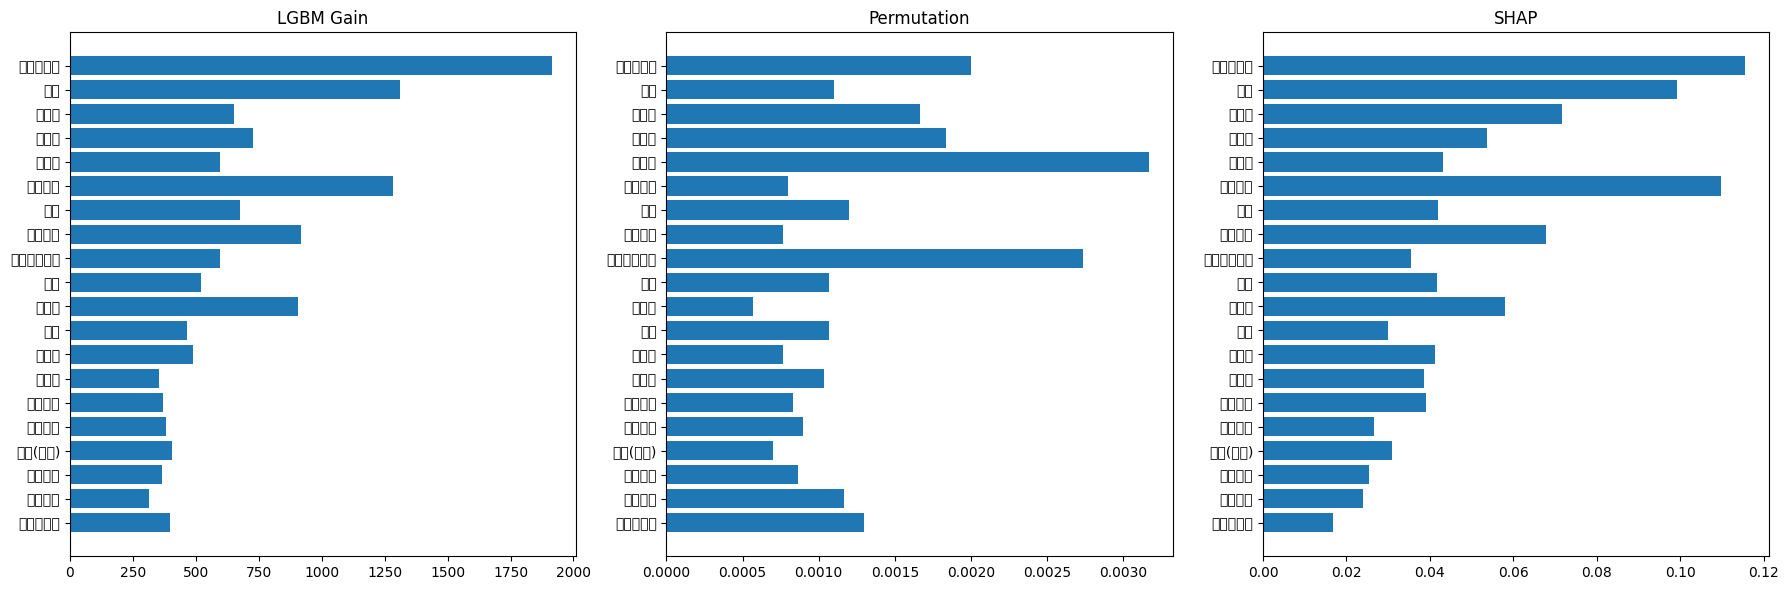

In [92]:
# ====================================================
# 6️⃣ 실행
# ====================================================

if __name__ == "__main__":
    try:
        cfg = Config()
        run_pipeline(cfg)
    except Exception as e:
        print(f"\n❌ 에러 발생: {e}")
        import traceback
        traceback.print_exc()